In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [6]:
print("Missing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df["Churn"].value_counts())
print("\nChurn percentage:\n", df["Churn"].value_counts(normalize=True * 100))

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [7]:
# Try converting TotalCharges to numeric, and see what fails
df["TotalCharges_numeric"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Rows where conversion failed (these become NaN)
print("Rows with invalid TotalCharges:", df["TotalCharges_numeric"].isnull().sum())
df[df["TotalCharges_numeric"].isnull()][["customerID", "tenure", "TotalCharges", "TotalCharges_numeric"]]

Rows with invalid TotalCharges: 11


,customerID,tenure,TotalCharges,TotalCharges_numeric
488,4472-LVYGI,0,,NaN
753,3115-CZMZD,0,,NaN
936,5709-LVOEQ,0,,NaN
1082,4367-NUYAO,0,,NaN
1340,1371-DWPAZ,0,,NaN
3331,7644-OMVMY,0,,NaN
3826,3213-VVOLG,0,,NaN
4380,2520-SGTTA,0,,NaN
5218,2923-ARZLG,0,,NaN
6670,4075-WKNIU,0,,NaN


In [8]:
# Since these are all customers with 0 tenure, it makes sense their TotalCharges is 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Drop the helper column we made for testing
df.drop("TotalCharges_numeric", axis=1, inplace=True)

# Verify the fix
print("Missing values now:", df["TotalCharges"].isnull().sum())
print("Data type now:", df["TotalCharges"].dtype)

Missing values now: 0
Data type now: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

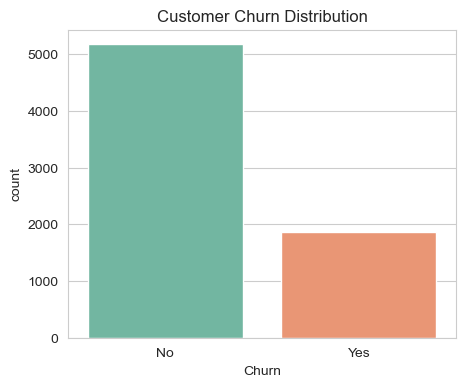

In [10]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df, hue="Churn", palette="Set2", legend=False)
plt.title("Customer Churn Distribution")
plt.savefig("../images/churn_distribution.png", bbox_inches="tight")
plt.show()

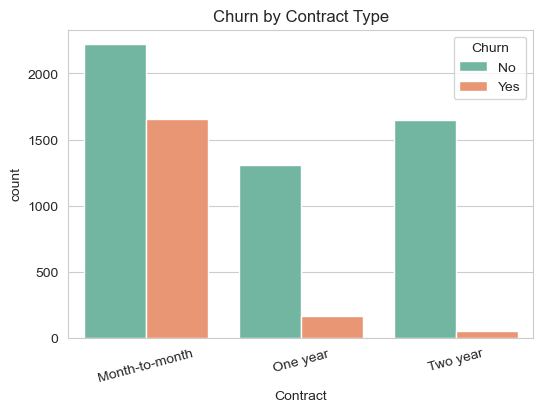

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Contract", hue="Churn", data=df, palette="Set2")
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.savefig("../images/churn_by_contract.png", bbox_inches="tight")
plt.show()

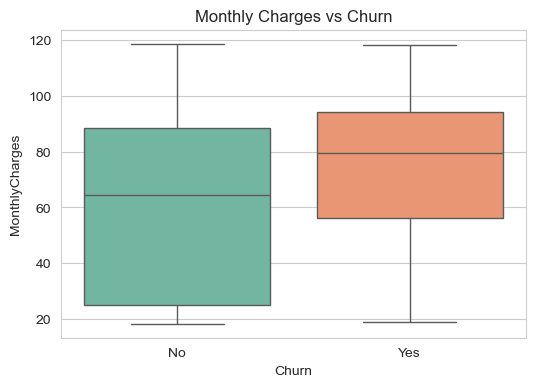

In [12]:
# Monthly charges vs churn
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, hue="Churn", palette="Set2", legend=False)
plt.title("Monthly Charges vs Churn")
plt.savefig("../images/monthlycharges_vs_churn.png", bbox_inches="tight")
plt.show()

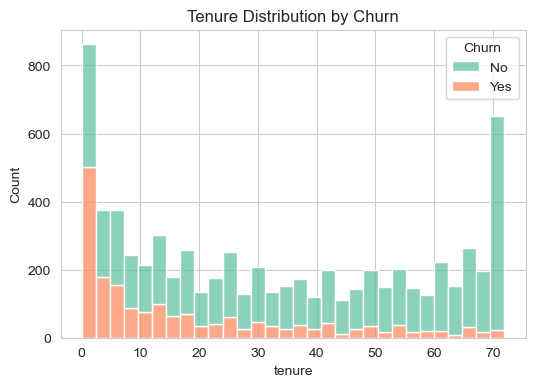

In [13]:
# Tenure vs churn
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, palette="Set2")
plt.title("Tenure Distribution by Churn")
plt.savefig("../images/tenure_vs_churn.png", bbox_inches="tight")
plt.show()

In [14]:
# Make a copy so we keep the original df for reference
df_model = df.copy()

# Encode the target column: Yes -> 1, No -> 0
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

# Drop customerID - it's just an identifier, not useful for prediction
df_model.drop("customerID", axis=1, inplace=True)

df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [15]:
from sklearn.preprocessing import LabelEncoder

# Find all columns that are still text (object type)
cat_cols = df_model.select_dtypes(include="object").columns
print("Categorical columns to encode:", cat_cols.tolist())

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [16]:
print(df_model.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [17]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5634, 19)
Test set: (1409, 19)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Sample of scaled training data:")
print(X_train_scaled[:3])

Scaling done. Sample of scaled training data:
[[ 0.99433624 -0.44177295 -0.96923413 -0.65155653  0.10237124 -3.01309011
   0.05525321 -1.18311574 -0.91955823 -1.0405346   1.24087411 -0.92792775
   1.13544459  1.13181864 -0.82777445 -1.20265302  0.40093316 -0.52197565
  -0.2622572 ]
 [ 0.99433624 -0.44177295  1.03174245  1.53478624 -0.71174346  0.3318852
  -0.99998941  0.17417892  1.40366647 -1.0405346  -1.02969579 -0.92792775
  -1.12261923 -1.12620764 -0.82777445 -1.20265302  1.33627784  0.33747781
  -0.50363479]
 [ 0.99433624 -0.44177295  1.03174245  1.53478624 -0.79315493 -3.01309011
   0.05525321 -1.18311574  1.40366647  1.22730754 -1.02969579  1.38942373
  -1.12261923 -1.12620764  1.56938887 -1.20265302  1.33627784 -0.80901319
  -0.74988292]]


In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Make predictions on test set
y_pred = log_model.predict(X_test_scaled)

print("First 20 predictions:", y_pred[:20])
print("First 20 actual values:", y_test.values[:20])

First 20 predictions: [0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]
First 20 actual values: [0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0]


In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nFull report:\n", classification_report(y_test, y_pred))

Accuracy : 0.7984386089425124
Precision: 0.640625
Recall   : 0.5481283422459893
F1 Score : 0.590778097982709
ROC-AUC  : 0.8403833733757008

Full report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



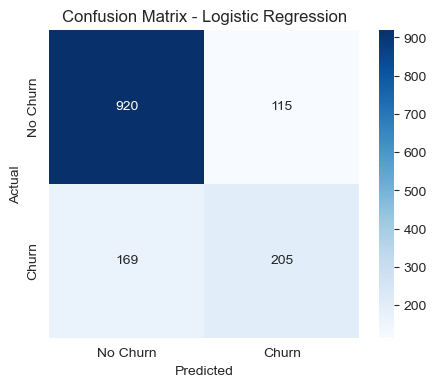

In [22]:
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("../images/confusion_matrix.png", bbox_inches="tight")
plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)  # Note: tree models don't need scaled data

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.7877927608232789
Precision: 0.6279863481228669
Recall   : 0.4919786096256685
F1 Score : 0.5517241379310345
ROC-AUC  : 0.8250678136867396


In [24]:
log_model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_model_balanced.fit(X_train_scaled, y_train)

y_pred_bal = log_model_balanced.predict(X_test_scaled)
y_prob_bal = log_model_balanced.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_bal))
print("Precision:", precision_score(y_test, y_pred_bal))
print("Recall   :", recall_score(y_test, y_pred_bal))
print("F1 Score :", f1_score(y_test, y_pred_bal))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_bal))

Accuracy : 0.7388218594748048
Precision: 0.5050847457627119
Recall   : 0.7967914438502673
F1 Score : 0.6182572614107884
ROC-AUC  : 0.839786612932393


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    param_grid,
    scoring="f1",
    cv=5
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 (cross-validated):", grid_search.best_score_)

best_log_model = grid_search.best_estimator_
y_pred_best = best_log_model.predict(X_test_scaled)
y_prob_best = best_log_model.predict_proba(X_test_scaled)[:, 1]

print("\nTest set performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))

Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 (cross-validated): 0.6280858658815841

Test set performance:
Accuracy : 0.7388218594748048
Precision: 0.5050847457627119
Recall   : 0.7967914438502673
F1 Score : 0.6182572614107884
ROC-AUC  : 0.8397969464465628


In [26]:
df_fe = df.copy()

# Tenure groups - bucket customers into lifecycle stages
df_fe["tenure_group"] = pd.cut(
    df_fe["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"],
    include_lowest=True
)

# Average monthly spend so far (catches billing patterns TotalCharges/MonthlyCharges alone miss)
df_fe["avg_monthly_spend"] = df_fe["TotalCharges"] / df_fe["tenure"].replace(0, 1)

# Count how many add-on services each customer has (engaged customers churn less)
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
df_fe["num_services"] = (df_fe[service_cols] == "Yes").sum(axis=1)

df_fe[["tenure", "tenure_group", "avg_monthly_spend", "num_services"]].head()

,tenure,tenure_group,avg_monthly_spend,num_services
0,1,0-1yr,29.850000,1
1,34,2-4yr,55.573529,2
2,2,0-1yr,54.075000,2
3,45,2-4yr,40.905556,3
4,2,0-1yr,75.825000,0


In [27]:
df_fe_model = df_fe.copy()

# Encode target
df_fe_model["Churn"] = df_fe_model["Churn"].map({"Yes": 1, "No": 0})

# Drop customerID
df_fe_model.drop("customerID", axis=1, inplace=True)

# Encode all categorical columns (including our new tenure_group)
cat_cols_fe = df_fe_model.select_dtypes(include=["object", "category"]).columns
print("Encoding:", cat_cols_fe.tolist())

le_fe = LabelEncoder()
for col in cat_cols_fe:
    df_fe_model[col] = le_fe.fit_transform(df_fe_model[col])

# Split features/target
X_fe = df_fe_model.drop("Churn", axis=1)
y_fe = df_fe_model["Churn"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

# Scale
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

# Train with best settings found + balanced class weight
final_model = LogisticRegression(C=1, penalty="l2", solver="liblinear",
                                   class_weight="balanced", max_iter=1000, random_state=42)
final_model.fit(X_train_fe_scaled, y_train_fe)

y_pred_final = final_model.predict(X_test_fe_scaled)
y_prob_final = final_model.predict_proba(X_test_fe_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test_fe, y_pred_final))
print("Precision:", precision_score(y_test_fe, y_pred_final))
print("Recall   :", recall_score(y_test_fe, y_pred_final))
print("F1 Score :", f1_score(y_test_fe, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test_fe, y_prob_final))

Encoding: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Accuracy : 0.7402413058907026
Precision: 0.5068493150684932
Recall   : 0.7914438502673797
F1 Score : 0.6179540709812108
ROC-AUC  : 0.8386886770518484


In [28]:
import joblib

# Save the final model and scaler
joblib.dump(final_model, "../models/churn_model.pkl")
joblib.dump(scaler_fe, "../models/scaler.pkl")

print("Model and scaler saved!")

Model and scaler saved!


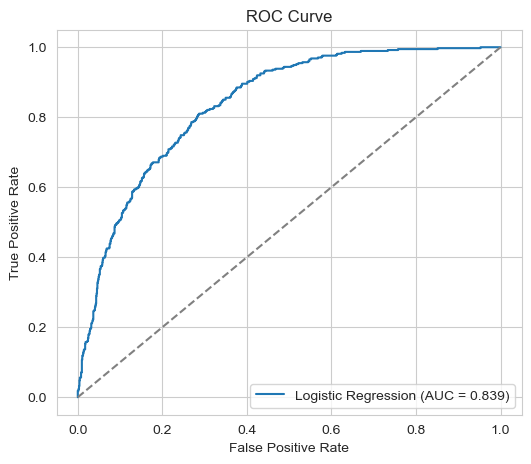

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test_fe, y_prob_final)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test_fe, y_prob_final):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("../images/roc_curve.png", bbox_inches="tight")
plt.show()

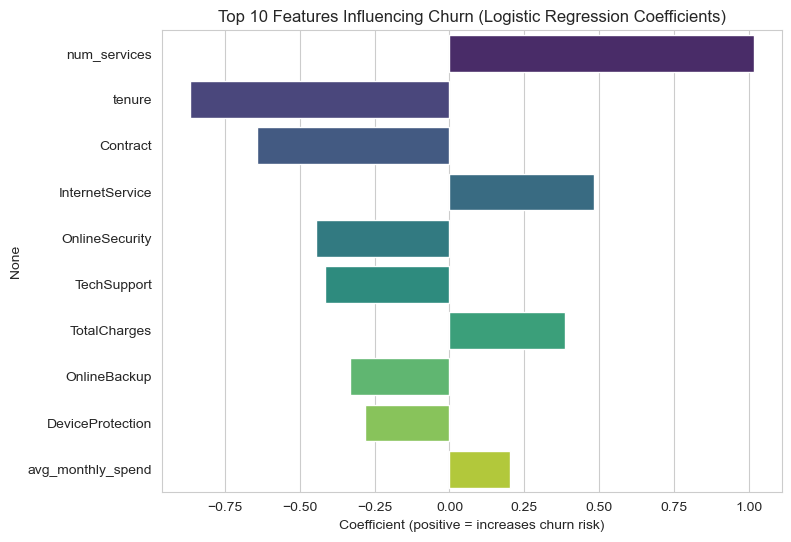

In [30]:
importance = pd.Series(final_model.coef_[0], index=X_fe.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importance.values[:10], y=importance.index[:10], hue=importance.index[:10], palette="viridis", legend=False)
plt.title("Top 10 Features Influencing Churn (Logistic Regression Coefficients)")
plt.xlabel("Coefficient (positive = increases churn risk)")
plt.savefig("../images/feature_importance.png", bbox_inches="tight")
plt.show()